In [1]:
using LinearAlgebra
using Plots

# Questão 1. Cálculo dos refletores

$(a)$ Temos $Q_vx=||x||_2e_1$, então:
$$(I−\beta vv^*)x=||x||_2e_1$$

$$\beta(v^*x)v = x - ||x||_2e_1$$

como $\beta(v^*x)$ é um escalar, estamos interessados somente na direção do vetor. podemos escolher:
$$v = x - ||x||_2e_1$$

Para isso, queremos $\beta(v^*x) = 1$. substituindo:
$$v^*x = (x - ||x||_2 e_1)^* x = ||x||_2^2 - ||x||_2x_1$$
$$= ||x||_2(||x||_2 - x_1)$$

Portanto:
$$\beta = \frac{1}{||x||_2(||x||_2 - x_1)}$$

Queremos obter as outras formas de calcular $\beta$:
$$\beta = \frac{1}{||x||_2(||x||_2 - x_1)} \cdot \frac{||x||_2 + x_1}{||x||_2 + x_1} = \frac{||x||_2 + x_1}{||x||_2(||x||_2^2 - x_1^2)}$$

Observe que:
$$||x||_2^2 = x_1^2 + x_2^2 + \dots + x_n^2$$
$$||x||_2^2 - x_1^2 = x_2^2 + \dots + x_n^2 = ||y||_2^2$$

Substituindo:
$$\beta = \frac{||x||_2 + x_1}{||x||_2(||x||_2^2 - x_1^2)} = \frac{||x||_2 + x_1}{||x||_2 \cdot ||y||_2^2}$$

---

$(b)$ Cancelamento numérico ocorre quando subtraímos dois números quase iguais. O resultado tem muito menos dígitos significativos do que os operandos.

Pensando no caso em que $x_1 > 0$ e $x$ está praticamente alinhado com $e_1$, ou seja:
$$ x \approx ||x||_2e_1 \Rightarrow ||x||_2 - x_1 \approx 0, ||x||_2^2 - x_1^2 \approx 0$$

se utlizarmos a primeira ou a segunda fórmula, teremos cancelamento numérico no denominador. Mas $||x||_2 + x_1$ nunca cancela. Assim, a terceira é a melhor opção nesse caso.

No caso em que $x_1 < 0$, tanto a fórmula 3 quanto a fórmula 2 não é uma boa escolha pois:
$$ x \approx -||x||_2e_1 \Rightarrow ||x||_2 + x_1 \approx 0, \ ||x||_2^2 - x_1^2 \approx 0$$

A melhor opção nesse caso é a primeira fórmula, onde não há cancelamento.

---

$(c)$ Utilizando os resultados obtidos nos itens anteiores, temos essa função abaixo

In [2]:
using LinearAlgebra

function reflector(x)
    norm_x = norm(x)

    v = copy(x)
    v[1] -= norm_x # muda somente a primeira coordenada

    if x[1] >= 0
        norm_y2 = sum(xi^2 for xi in x[2:end])  # ||y||² direto, sem cancelamento
        beta = (norm_x + x[1]) / (norm_x * norm_y2)
    else
        beta = one(eltype(x)) / (norm_x * (norm_x - x[1])) # eltype para 'não promover tipos'
    end

    return v, beta
end


reflector (generic function with 1 method)

---

$(d)$ Iremos calcular o Jacobiano $J = \frac{\partial v}{\partial x}$. Temos $v = x − ||x||_2 e_1$, então componente a componente:
$$v_i = x_i − ||x||(e_1)_i$$

primeiramente a derivada de $||x||_2$ em relação a cada componente $x_j$:
$$\frac{\partial}{\partial x_j}\sqrt{x_1^2 + x_2^2 + \dots + x_j^2 + \dots + x_n^2} = \frac{1}{2\sqrt{x_1^2 + x_2^2 + \dots + x_j^2 + \dots + x_n^2}} \cdot 2x_j = \frac{x_j}{||x||_2}$$

Portanto:
$$\frac{\partial v_i}{\partial x_j} = \frac{\partial }{\partial x_j}(x_i − ||x||(e_1)_i) = \delta_{ij} - (e_1)_i\frac{x_j}{||x||_2} $$

com $
\delta_{ij} =
\begin{cases}
1, & \text{se } i = j, \\
0, & \text{se } i \neq j.
\end{cases}
$. Montando a matriz J:

$$
J = 
\begin{bmatrix}
\frac{\partial v_1}{\partial x_1} & \frac{\partial v_1}{\partial x_2} & \cdots & \frac{\partial v_1}{\partial x_n} \\
\frac{\partial v_2}{\partial x_1} & \frac{\partial v_2}{\partial x_2} & \cdots & \frac{\partial v_2}{\partial x_n} \\
\vdots & \vdots & \ddots & \vdots \\
\frac{\partial v_n}{\partial x_1} & \frac{\partial v_n}{\partial x_2} & \cdots & \frac{\partial v_n}{\partial x_n}
\end{bmatrix}

= 
\begin{bmatrix}
1 - \frac{x_1}{||x||_2} & -\frac{x_2}{||x||_2} & -\frac{x_3}{||x||_2} & \cdots & -\frac{x_n}{||x||_2} \\
0 & 1 & 0 & \cdots & 0 \\
0 & 0 & 1 &\cdots & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
0 & 0 & 0 & \cdots & 1
\end{bmatrix}
= I - \frac{e_1x^*}{||x||_2} 
$$

Para mostrar que o condicionamento absoluto $k_{abs} \leq 2$ precisaremos de três resultados importantes:

$(i)$ $||A + B||_p \leq ||A||_p + ||B||_p$

Tome $x$ vetor de norma 1

$$||(A + B)x||_p = ||Ax + Bx||_p \leq ||Ax||_p + ||Bx||_p \leq ||A||_p + ||B||_p$$

$(ii)$ $||-A||_p = ||A||_p$

$$||-Ax||_p = ||A(-x)||_p \leq ||A||_p||-x||_p = ||A||_p||x||_p$$

$(iii)$ $||uv^*||_2 = ||u||_2||v||_2$

$$||uv^*x||_2 = ||u||_2|v^*x|$$

Por Cauchy-Schwarz:
$$||u||_2|v^*x| \leq ||u||_2||v||_2||x||_2$$
$$\Rightarrow \frac{||uv^*x||_2 }{||x||_2} \leq ||u||_2||v||_2$$

Tomando $x = \frac{v}{||v||_2}$ unitário:
$$\frac{||uv^*v||_2/||v||_2}{||x||_2} = \frac{||u||_2||v||_2^2}{||v||_2} = ||u||_2||v||_2$$

Com isso, temos então:
$$||I - \frac{e_1x^*}{||x||_2}||_2 \leq ||I||_2 + \frac{||e_1x^*||}{||x||_2} = ||I||_2 + \frac{||e||_2||x||_2}{||x||_2} = 1 + 1 = 2$$

Aqui abaixo temos um código com alguns testes para mostrar na prática com $x = (cos\theta, sen\theta), 0 \leq \theta \leq 2\pi$ girando no $\mathbb{R}^2$

valor maximo: 1.9999584625974336


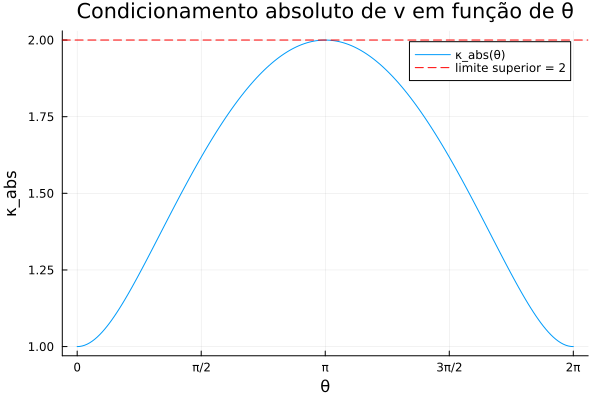

In [18]:
function jacobiano(x)
    n = length(x)
    norm_x = norm(x)
    # J = I - e1 * x' / ||x||
    J = Matrix{Float64}(I, n, n)
    J[1, :] -= x / norm_x # modifica somente a primeira linha
    return J
end

thetas = range(0, 2π, length = 200)
cond = []
for θ in thetas
    x = [cos(θ), sin(θ)]
    push!(cond, maximum(svdvals(jacobiano(x)))
)
end
println("valor maximo: ", maximum(cond))

plot(thetas, cond,
    xlabel = "θ",
    ylabel = "κ_abs",
    title  = "Condicionamento absoluto de v em função de θ",
    label  = "κ_abs(θ)",
    xticks = ([0, π/2, π, 3π/2, 2π], ["0", "π/2", "π", "3π/2", "2π"]),
    hline! = [2.0],  # linha de referência no limite superior
)
hline!([2.0], label="limite superior = 2", linestyle=:dash, color=:red)

Nesse caso, quanto mais longe $x$ está de $e_1$ mais $v$ "estica" as perturbações e $\theta = \pi$ é o ponto mais distante de $e_1$ no círculo.

---

$(e)$

$(f)$

$(g)$ (Bônus)

# Questão 2. Forma de Hessemberg

$(a)$

$(b)$

$(c)$

$(d)$

$(e)$

$(f)$

# Questão 3. Exponenciais de matrizes

$(a)$

$(b)$

$(c)$ (Bônus)